In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import random
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Q1

In [22]:
df = pd.read_csv(
    "early_2012_2013_loan_sample_with_outcome.txt",
    sep=","
)

print(f'Raw shape: {df.shape}')
df.info()
df.describe(include='all')

Raw shape: (50000, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  int64  
 3   funded_amnt                  50000 non-null  int64  
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  float64
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  object 
 9   sub_grade                    50000 non-null  object 
 10  emp_title                    47168 non-null  object 
 11  emp_length                   48198 non-null  float64
 12  home_ownership               50000 non-null  object

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_credit_rv,loan_is_bad
count,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000,47168,48198.000000,50000,5.000000e+04,50000,50000,50000,50000,31004,50000,49998,50000,50000,50000.000000,50000.000000,50000,50000.00000,21874.000000,2532.000000,50000.00000,50000.000000,5.000000e+04,49969,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49957,50000.000000,7136,50000,50000.000000,7120.000000,50000.0,50000,50000.000000,35382.000000,3.538200e+04,3.538200e+04,50000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,35,37229,NaN,5,NaN,3,10,7,2,30822,13,15531,799,46,NaN,NaN,544,NaN,NaN,NaN,NaN,NaN,NaN,1013,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43,NaN,2,44,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,B3,US Army,NaN,MORTGAGE,NaN,Verified,Jan-2013,Fully Paid,n,Borrower added on 01/14/13 > Debt consolidat...,debt_consolidation,Debt consolidation,112xx,CA,NaN,NaN,Oct-2000,NaN,NaN,NaN,NaN,NaN,NaN,0%,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dec-2015,NaN,Jan-2016,Dec-2015,NaN,NaN,NaN,INDIVIDUAL,NaN,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17859,5011,188,NaN,24784,NaN,21867,6871,35565,49997,6,29850,5507,646,8457,NaN,NaN,473,NaN,NaN,NaN,NaN,NaN,NaN,169,NaN,43189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8867,NaN,5907,24668,NaN,NaN,NaN,50000,NaN,NaN,NaN,NaN,42186
mean,1.918444e+06,2.283786e+06,13901.202000,13896.232000,13877.691336,40.492320,13.997130,436.954180,NaN,NaN,NaN,5.992801,NaN,7.131682e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.373081,0.224440,NaN,0.83888,36.080598,87.704976,11.00528,0.056480,1.601082e+04,NaN,24.314920,NaN,843.203298,842.111277,14827.540409,14807.632219,11611.058424,3071.491116,0.841868,144.149011,10.662802,NaN,3569.007130,NaN,NaN,0.001140,42.307865,1.0,NaN,0.000820,51.995704,1.335940e+05,2.929955e+04,NaN
std,6.389890e+05,8.024902e+05,8086.390575,8081.255517,8072.373068,9.361437,4.280414,245.782294,NaN,NaN,NaN,3.429436,NaN,6.747482e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.765797,0.671383,NaN,1.02099,21.493740,24.717100,4.54279,0.265954,1.843776e+04,NaN,11.027608,NaN,2949.736550,2946.173297,9489.452176,9478.955450,7591.581269,3157.741978,5.933666,699.708130,83.735784,NaN,5529.437766,NaN,NaN,0.036038,20.909450,0.0,NaN,0.034342,659.738943,1.568073e+05,2.896408e+04,NaN
min,5.852400e+04,1.495120e+05,1000.000000,1000.000000,950.000000,36.000000,6.000000,25.810000,NaN,NaN,NaN,1.000000,NaN,5.000000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.00000,0.000000,2.000000,0.00000,0.000000,0.000000e+00,NaN,2.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,1.0,NaN,0.000000,0.000000,0.000000e+00,0.000000e+00,NaN
25%,1.443048e+06,1.695278e+06,8000.000000,8000.000000,7950.000000,36.000000,11.140000,255.660000,NaN,NaN,NaN,3.000000,NaN,4.500000e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.510000,0.000000,NaN,0.00000,18.000000,76.000000,8.00000,0.000000,7.101750e+03,NaN,16.000000,NaN,0.000000,0.000000,7613.995108,7601.267500,6000.000000,1057.515000,0.000000,0.000000,0.000000,NaN,353.140000,NaN,NaN,0.000000,25.000000,1.0,NaN,0.000000,0.000000,2.629750e+04,1.400000

In [23]:
# 1. DROPPING IRRELEVANT / REDUNDANT COLUMNS
# ─────────────────────────────────────────
# Identifiers — no predictive power
# Free text/high-cardinality — unstructured
# Zero-variance — policy_code= 1 only, application_type ='INDIVIDUAL' only
# Near-zero-variance — pymnt_plan: 49,997 'n' vs 3 'y'
# Post-origination leakage — recorded after loan outcome is known
# Redundant dates — only available after loan closes
# Duplicate column — tot_coll_amt2 = tot_coll_amt

cols_to_drop = [
    'id', 'member_id',                                        # identifiers
    'emp_title', 'title', 'desc', 'zip_code',                 # free text
    'policy_code', 'application_type', 'pymnt_plan',          # zero/near-zero variance
    'funded_amnt_inv', 'out_prncp', 'out_prncp_inv',          # leakage
    'total_pymnt', 'total_pymnt_inv',                         # leakage
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', # leakage
    'recoveries', 'collection_recovery_fee',                  # leakage
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',        # post-outcome dates
    'last_credit_pull_d',                                      # post-outcome date
    'tot_coll_amt2',                                           # duplicate
]

dfclean = df.drop(columns=cols_to_drop, errors='ignore')
print(f'After drop: {dfclean.shape[1]} columns remaining')

After drop: 34 columns remaining


                             Count    Pct
mths_since_last_record       47468  94.94
mths_since_last_major_derog  42880  85.76
mths_since_last_delinq       28126  56.25
tot_coll_amt                 14618  29.24
tot_cur_bal                  14618  29.24
total_credit_rv              14618  29.24
emp_length                    1802   3.60
revol_util                      31   0.06


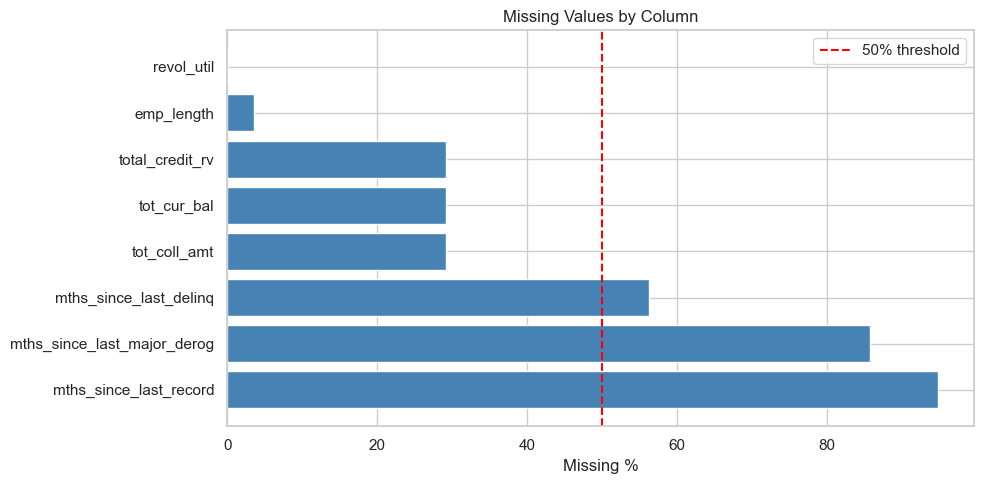

In [24]:
# 2. MISSING VALUE ANALYSIS
# ─────────────────────────────────────────
missing = dfclean.isnull().sum()
missing_pct = (missing / len(dfclean) * 100).round(2)
missing_df = (
    pd.DataFrame({'Count': missing, 'Pct': missing_pct})
    .query('Count > 0')
    .sort_values('Pct', ascending=False)
)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_df.index, missing_df['Pct'], color='steelblue')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# 3. HANDLE MISSING VALUES
# ─────────────────────────────────────────
# mths_since_last_record      94.9% → drop (most borrowers have no public record)
# mths_since_last_major_derog 85.8% → drop
# tot_coll_amt                56.3% → drop
# tot_cur_bal                 29.2% → drop (same cohort missing as total_credit_rv)
# total_credit_rv             29.2% → drop
# revol_util                   0.06% → drop rows (only 31 rows)
# emp_length                   3.6%  → fill with median (reasonable imputation)

cols_high_missing = [
    'mths_since_last_record', 'mths_since_last_major_derog',
    'tot_coll_amt', 'tot_cur_bal', 'total_credit_rv'
]
dfclean = dfclean.drop(columns=cols_high_missing, errors='ignore')
dfclean = dfclean.dropna(subset=['revol_util'])

emp_median = dfclean['emp_length'].median()
dfclean['emp_length'] = dfclean['emp_length'].fillna(emp_median)

print('Missing after treatment:')
print(dfclean.isnull().sum()[dfclean.isnull().sum() > 0])
print(f'\nShape: {dfclean.shape}')

Missing after treatment:
mths_since_last_delinq    28108
dtype: int64

Shape: (49969, 29)


In [26]:
# 4. DATA TYPE CONVERSION
# ─────────────────────────────────────────

# Ordinal categories (natural ordering)
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
dfclean['grade'] = pd.Categorical(dfclean['grade'], categories=grade_order, ordered=True)

sub_grade_order = sorted(dfclean['sub_grade'].unique())
dfclean['sub_grade'] = pd.Categorical(dfclean['sub_grade'], categories=sub_grade_order, ordered=True)

# Nominal categories
nominal_cats = [
    'home_ownership', 'verification_status', 'loan_status',
    'purpose', 'addr_state', 'initial_list_status'
]
for col in nominal_cats:
    dfclean[col] = dfclean[col].astype('category')

# Integer columns (counts and whole-dollar amounts)
int_cols = [
    'loan_amnt', 'funded_amnt', 'term', 'emp_length',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq'
]
for col in int_cols:
    if col in dfclean.columns:
        dfclean[col] = dfclean[col].astype(int)

print('Updated dtypes:')
print(dfclean.dtypes)

Updated dtypes:
loan_amnt                        int64
funded_amnt                      int64
term                             int64
int_rate                       float64
installment                    float64
grade                         category
sub_grade                     category
emp_length                       int64
home_ownership                category
annual_inc                     float64
verification_status           category
issue_d                         object
loan_status                   category
purpose                       category
addr_state                    category
dti                            float64
delinq_2yrs                      int64
earliest_cr_line                object
inq_last_6mths                   int64
mths_since_last_delinq         float64
open_acc                         int64
pub_rec                          int64
revol_bal                        int64
revol_util                      object
total_acc                        int64
initial_l

In [27]:
# 5. OUTLIER DETECTION — IQR METHOD
# ─────────────────────────────────────────
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            'Column': col,
            'Q1': round(Q1, 2),  'Q3': round(Q3, 2),
            'Lower Fence': round(lower, 2), 'Upper Fence': round(upper, 2),
            'Outliers': n_out, 'Outlier %': round(100 * n_out / len(df), 2)
        })
    return pd.DataFrame(rows).set_index('Column')

numeric_cols = dfclean.select_dtypes(include=['int64', 'float64']).columns.tolist()
outlier_cols = [c for c in numeric_cols if c != 'loan_is_bad']

iqr_outlier_summary(dfclean, outlier_cols)

,Q1,Q3,Lower Fence,Upper Fence,Outliers,Outlier %
Column,,,,,,
loan_amnt,8000.00,19200.00,-8800.00,36000.00,0,0.00
funded_amnt,8000.00,19200.00,-8800.00,36000.00,0,0.00
term,36.00,36.00,36.00,36.00,9355,18.72
int_rate,11.14,17.27,1.95,26.46,0,0.00
installment,255.71,567.04,-211.28,1034.03,1279,2.56
emp_length,3.00,10.00,-7.50,20.50,0,0.00
annual_inc,45000.00,85000.00,-15000.00,145000.00,2288,4.58
dti,11.51,23.05,-5.80,40.36,0,0.00
delinq_2yrs,0.00,0.00,0.00,0.00,7542,15.09


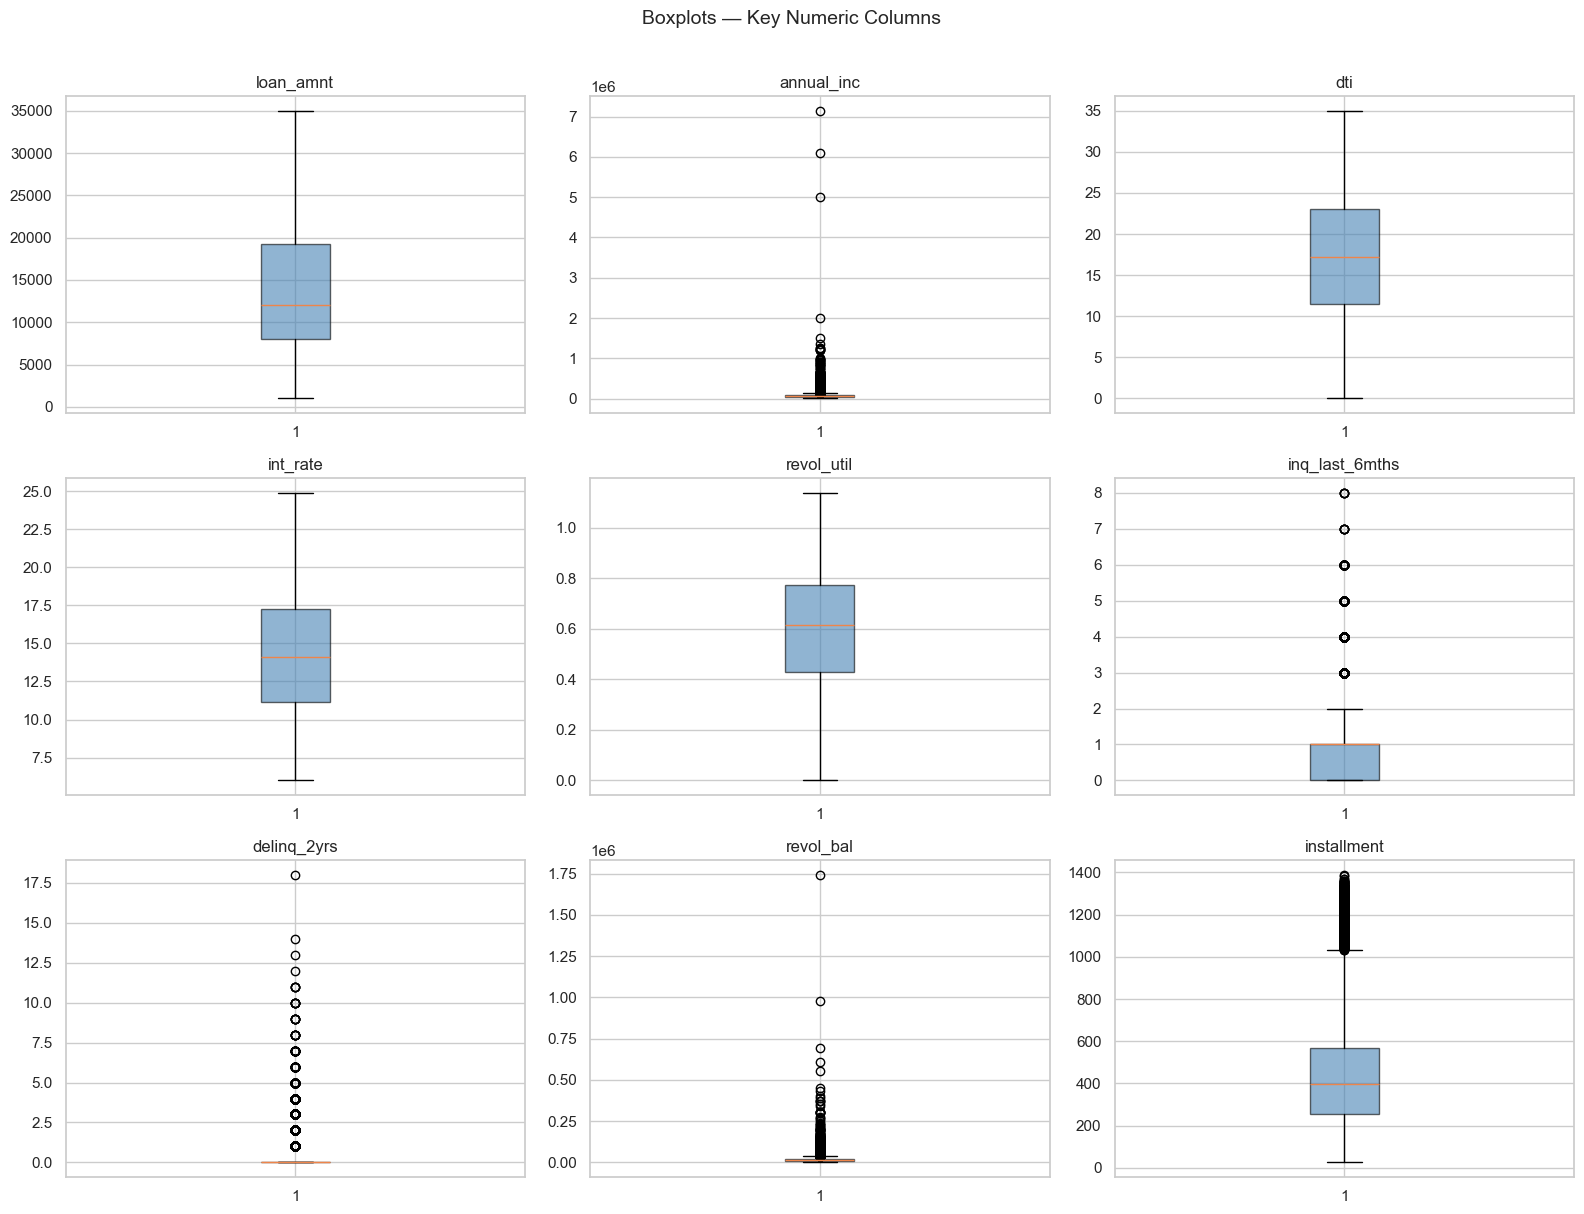

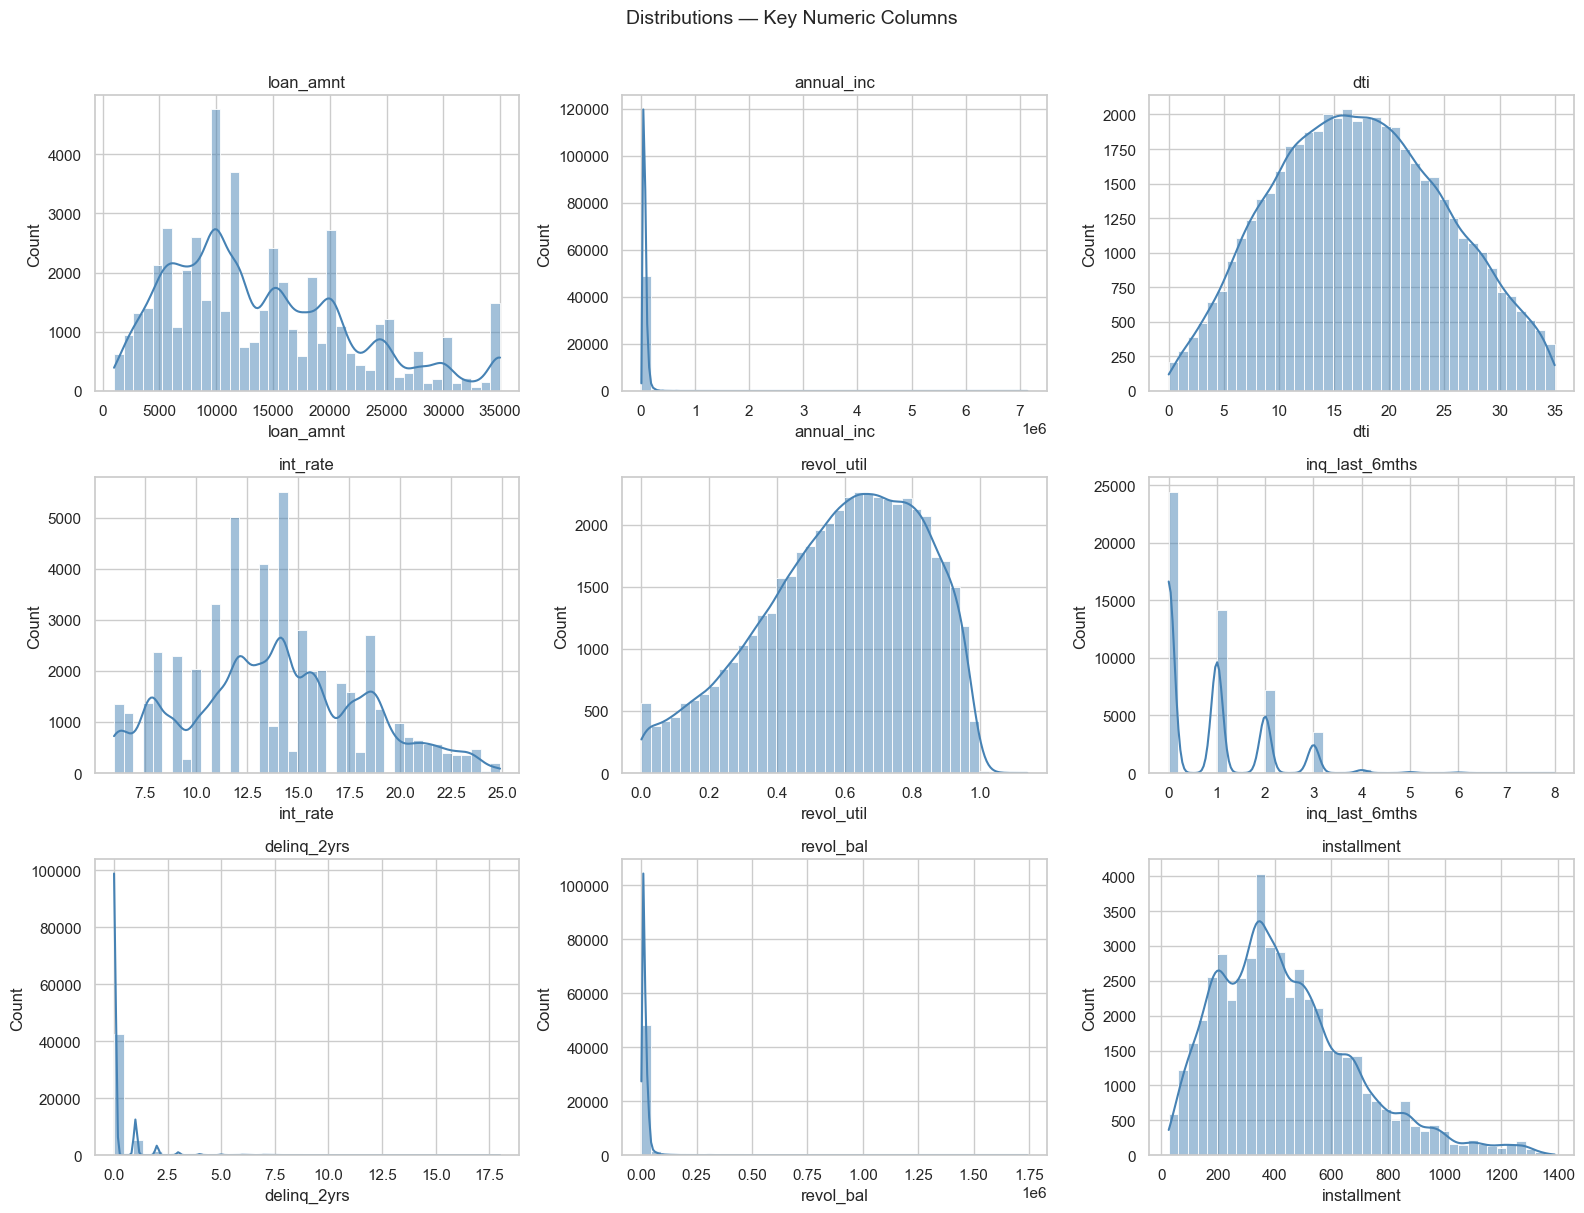

In [28]:
# ============================================================
# FIX NUMERIC COLUMNS BEFORE PLOTTING
# ============================================================

# 1. Fix percentage columns: remove '%' and convert to float
if 'revol_util' in dfclean.columns:
    dfclean['revol_util'] = (
        dfclean['revol_util']
        .astype(str)
        .str.replace('%', '', regex=False)
        .astype(float)
        / 100
    )

if 'int_rate' in dfclean.columns:
    dfclean['int_rate'] = (
        dfclean['int_rate']
        .astype(str)
        .str.replace('%', '', regex=False)
        .astype(float)
    )

# 2. Define key numeric columns
key_numeric = [
    'loan_amnt', 'annual_inc', 'dti', 'int_rate', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'revol_bal', 'installment'
]

# 3. Force conversion to numeric (coerce invalid to NaN → safe for plotting)
dfclean[key_numeric] = dfclean[key_numeric].apply(
    pd.to_numeric, errors='coerce'
)

# ============================================================
# BOXPLOTS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric):
    ax.boxplot(
        dfclean[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6)
    )
    ax.set_title(col)

plt.suptitle('Boxplots — Key Numeric Columns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# HISTOGRAMS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric):
    sns.histplot(
        dfclean[col].dropna(),
        bins=40,
        kde=True,
        ax=ax,
        color='steelblue'
    )
    ax.set_title(col)

plt.suptitle('Distributions — Key Numeric Columns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# 6. OUTLIER TREATMENT
# ─────────────────────────────────────────
# annual_inc  → Winsorise at 99th pct — max $7.1M vs median $58k, genuine distortion
# revol_bal   → Winsorise at 99th pct — 500 rows above $70k cap (1% of data)
# revol_util  → Hard cap at 1.0 — only 19 rows above 100%, clear data entry error
# inq_last_6mths, delinq_2yrs → KEEP — high counts are genuine credit risk signals

cap_income = dfclean['annual_inc'].quantile(0.99)
cap_revol  = dfclean['revol_bal'].quantile(0.99)

annual_inc_before = dfclean['annual_inc'].copy()

dfclean['annual_inc'] = dfclean['annual_inc'].clip(upper=cap_income)
dfclean['revol_bal']  = dfclean['revol_bal'].clip(upper=cap_revol)
dfclean['revol_util'] = dfclean['revol_util'].clip(upper=1.0)

print(f'annual_inc: capped at {cap_income:,.0f} — affected {(annual_inc_before > cap_income).sum()} rows')
print(f'revol_bal:  capped at {cap_revol:,.0f}  — affected {(df["revol_bal"] > cap_revol).sum()} rows')
print(f'revol_util: capped at 1.0  — affected 19 rows (data entry errors only)')


annual_inc: capped at 225,000 — affected 495 rows
revol_bal:  capped at 70,873  — affected 500 rows
revol_util: capped at 1.0  — affected 19 rows (data entry errors only)


In [30]:
# 7. FINAL CHECK & SAVE
# ─────────────────────────────────────────
print(f'Final shape: {dfclean.shape}')
print(f'Missing values: {dfclean.isnull().sum().sum()}')
print(dfclean.dtypes)

dfclean.to_pickle('dfclean.pkl')
print('\nSaved → dfclean.pkl  (ready for Information Gain step)')

Final shape: (49969, 29)
Missing values: 28108
loan_amnt                        int64
funded_amnt                      int64
term                             int64
int_rate                       float64
installment                    float64
grade                         category
sub_grade                     category
emp_length                       int64
home_ownership                category
annual_inc                     float64
verification_status           category
issue_d                         object
loan_status                   category
purpose                       category
addr_state                    category
dti                            float64
delinq_2yrs                      int64
earliest_cr_line                object
inq_last_6mths                   int64
mths_since_last_delinq         float64
open_acc                         int64
pub_rec                          int64
revol_bal                      float64
revol_util                     float64
total_acc        

In [31]:
# 9. INFORMATION GAIN (Mutual Information)
# ─────────────────────────────────────────
# MI measures how much knowing a feature reduces uncertainty about loan_is_bad.
# Unlike Pearson correlation it captures non-linear relationships too.
# Absolute scores are always small — what matters is the RANKING.

candidate_features = [
    'grade', 'int_rate', 'dti', 'annual_inc', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'loan_amnt', 'emp_length',
    'home_ownership', 'term'
]
target = 'loan_is_bad'

df_mi = dfclean[candidate_features + [target]].copy()

# Encode grade (ordinal: A=1 → G=7)
df_mi['grade'] = dfclean['grade'].cat.codes + 1

# Encode home_ownership (nominal → integer)
df_mi['home_ownership'] = LabelEncoder().fit_transform(
    df_mi['home_ownership'].astype(str))

# Bin continuous variables — use uniform (equal-width) not quantile
# because quantile on low-cardinality cols like emp_length collapses bins
continuous_cols = ['int_rate', 'dti', 'annual_inc', 'revol_util', 'loan_amnt']
low_cardinality  = ['emp_length']   # only 10 unique values → use 5 bins max

kb_cont = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
kb_low  = KBinsDiscretizer(n_bins=5,  encode='ordinal', strategy='uniform')

df_mi[continuous_cols] = kb_cont.fit_transform(df_mi[continuous_cols])
df_mi[low_cardinality]  = kb_low.fit_transform(df_mi[low_cardinality])

# Compute MI
X = df_mi.drop(columns=[target])
y = df_mi[target].astype(int)

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = (
    pd.DataFrame({'Feature': X.columns, 'Information_Gain': mi_scores})
    .sort_values('Information_Gain', ascending=False)
    .reset_index(drop=True)
)

print(mi_results.to_string(index=False))

       Feature  Information_Gain
         grade          0.020124
      int_rate          0.017545
          term          0.005936
           dti          0.004371
    annual_inc          0.004304
    revol_util          0.002383
inq_last_6mths          0.002347
home_ownership          0.002096
     loan_amnt          0.001641
   delinq_2yrs          0.001629
    emp_length          0.000737


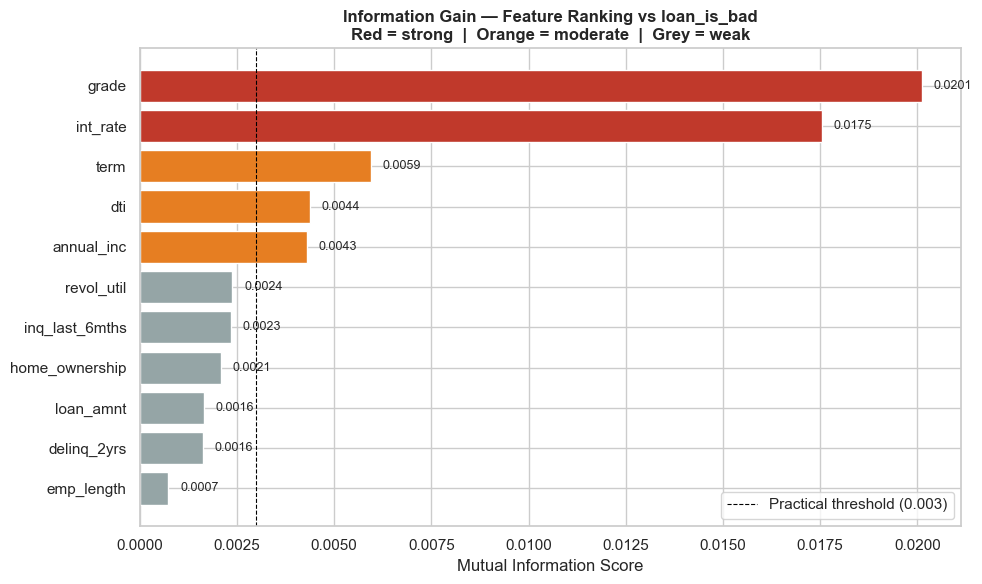

In [32]:
# Visualise 
# ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

palette = ['#c0392b' if v > 0.008 else '#e67e22' if v > 0.003 else '#95a5a6'
           for v in mi_results['Information_Gain']]

ax.barh(mi_results['Feature'][::-1],
        mi_results['Information_Gain'][::-1],
        color=palette[::-1], edgecolor='white', linewidth=1)

for i, (feat, val) in enumerate(zip(mi_results['Feature'][::-1],
                                     mi_results['Information_Gain'][::-1])):
    ax.text(val + 0.0003, i, f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.003, color='black', linestyle='--', linewidth=0.8,
           label='Practical threshold (0.003)')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Information Gain — Feature Ranking vs loan_is_bad\n'
             'Red = strong  |  Orange = moderate  |  Grey = weak',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# 10. POLICY THRESHOLD DESIGN
# Primary variable  : Grade
# Secondary variable: Dti
# ─────────────────────────────────────────

# Policy A (Control): grade in {A,B,C,D} AND dti <= 25
#   -> accepts up to 1.5x average default rate (grade D=23%)
#   -> DTI above Q3 -- only rejects the most indebted borrowers (loose)
#
# Policy B (Treatment): grade in {A,B,C} AND dti <= 20
#   -> stays near average default rate (grade C=17.9%)
#   -> DTI near median -- rejects above-average debt load (strict)


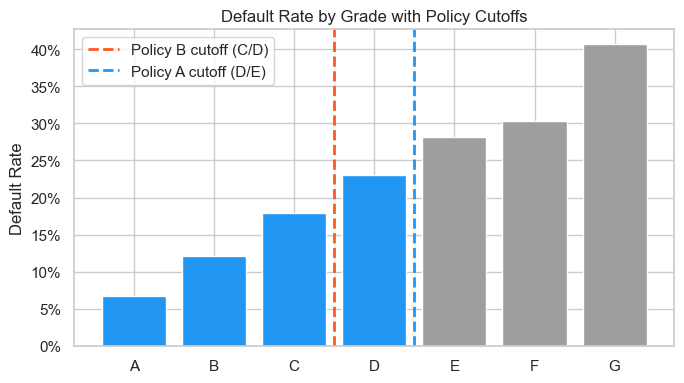

In [34]:
grade_dr = dfclean.groupby('grade', observed=True)['loan_is_bad'].mean().reindex(grade_order)

plt.figure(figsize=(7, 4))
colours = ['#2196F3' if g in ['A','B','C','D'] else '#9E9E9E' for g in grade_order]
plt.bar(grade_order, grade_dr, color=colours)
plt.axvline(2.5, color='#FF5722', linestyle='--', linewidth=2, label='Policy B cutoff (C/D)')
plt.axvline(3.5, color='#2196F3', linestyle='--', linewidth=2, label='Policy A cutoff (D/E)')
plt.ylabel('Default Rate')
plt.title('Default Rate by Grade with Policy Cutoffs')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend()
plt.tight_layout()
plt.savefig('fig1_grade.png', dpi=150)
plt.show()


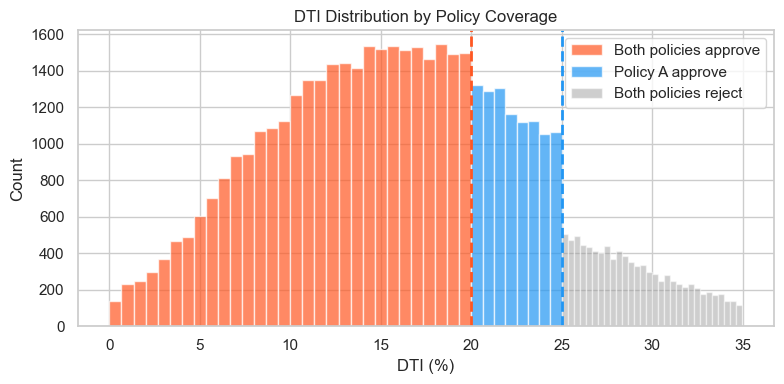

In [36]:
plt.figure(figsize=(8, 4))
plt.hist(dfclean.loc[dfclean['dti'] <= 20, 'dti'],           bins=30, color='#FF5722', alpha=0.7, label='Both policies approve')
plt.hist(dfclean.loc[(dfclean['dti'] > 20) & (dfclean['dti'] <= 25), 'dti'], bins=8,  color='#2196F3', alpha=0.7, label='Policy A approve')
plt.hist(dfclean.loc[dfclean['dti'] > 25, 'dti'],           bins=30, color='#9E9E9E', alpha=0.5, label='Both policies reject')
plt.axvline(20, color='#FF5722', linestyle='--', linewidth=2)
plt.axvline(25, color='#2196F3', linestyle='--', linewidth=2)
plt.xlabel('DTI (%)')
plt.ylabel('Count')
plt.title('DTI Distribution by Policy Coverage')
plt.legend()
plt.tight_layout()
plt.savefig('fig3_dti.png', dpi=150)
plt.show()

In [16]:
# 11. OEC AND HYPOTHESIS 
# ─────────────────────────────────────────

print("""
OEC: Default rate among approved loans = defaults approved / total approved

H0: policy_A = policy_B  (no difference in default rate)
H1: policy_A > policy_B  (Policy A has higher default rate than B)

One-sided test — Policy B is designed to be more conservative
so we expect it to produce fewer defaults. """)


OEC: Default rate among approved loans = defaults approved / total approved

H0: policy_A = policy_B  (no difference in default rate)
H1: policy_A > policy_B  (Policy A has higher default rate than B)

One-sided test — Policy B is designed to be more conservative
so we expect it to produce fewer defaults. 


In [38]:
# SUMMARY STATISTICS
# ─────────────────────────────────────────

grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Policy definitions
approved_A = dfclean[(dfclean['grade'].isin(['A','B','C','D'])) & (dfclean['dti'] <= 25)].copy()
approved_B = dfclean[(dfclean['grade'].isin(['A','B','C']))     & (dfclean['dti'] <= 20)].copy()

# Convert to int explicitly 
approved_A['loan_is_bad'] = approved_A['loan_is_bad'].astype(int)
approved_B['loan_is_bad'] = approved_B['loan_is_bad'].astype(int)

n_total = len(dfclean)
n_A     = len(approved_A)
n_B     = len(approved_B)
bad_A   = approved_A['loan_is_bad'].sum()
bad_B   = approved_B['loan_is_bad'].sum()
dr_A    = bad_A / n_A
dr_B    = bad_B / n_B


summary = pd.DataFrame({
    'Policy'       : ['Policy A (Expansionary)', 'Policy B (Conservative)'],
    'Grades'       : ['A, B, C, D', 'A, B, C'],
    'DTI limit'    : ['≤ 25%', '≤ 20%'],
    'Approved (n)' : [n_A, n_B],
    'Approval rate': [f'{n_A/n_total:.1%}', f'{n_B/n_total:.1%}'],
    'Default rate' : [f'{dr_A:.2%}', f'{dr_B:.2%}'],
    'Avg loan ($)' : [f'{approved_A["loan_amnt"].mean():,.0f}',
                      f'{approved_B["loan_amnt"].mean():,.0f}'],
    'Avg int rate' : [f'{approved_A["int_rate"].mean():.2f}%',
                      f'{approved_B["int_rate"].mean():.2f}%'],
})
print(summary.T)

                                     0                        1
Policy         Policy A (Expansionary)  Policy B (Conservative)
Grades                      A, B, C, D                  A, B, C
DTI limit                        ≤ 25%                    ≤ 20%
Approved (n)                     37438                    24905
Approval rate                    74.9%                    49.8%
Default rate                    13.51%                   11.33%
Avg loan ($)                    13,085                   12,706
Avg int rate                    13.08%                   11.99%


In [39]:
# ══════════════════════════════════════════════════════
# SECTION 4 – STATISTICAL TEST
# ══════════════════════════════════════════════════════

z, p_one = proportions_ztest([bad_A, bad_B], [n_A, n_B], alternative='larger')
# _, p_two = proportions_ztest([bad_A, bad_B], [n_A, n_B], alternative='two-sided')

diff    = dr_A - dr_B
se      = np.sqrt(dr_A*(1-dr_A)/n_A + dr_B*(1-dr_B)/n_B)
ci_lo   = diff - 1.96*se
ci_hi   = diff + 1.96*se

# Cohen's h — effect size for proportions
cohens_h = 2*np.arcsin(np.sqrt(dr_A)) - 2*np.arcsin(np.sqrt(dr_B))
if   abs(cohens_h) < 0.2: h_label = 'small'
elif abs(cohens_h) < 0.5: h_label = 'medium'
else:                      h_label = 'large'

print(f'Default rate A      : {dr_A:.4f} ({dr_A:.2%})')
print(f'Default rate B      : {dr_B:.4f} ({dr_B:.2%})')
print(f'Difference (p_A-p_B): {diff:.4f} ({diff:.2%})')
print(f'95% CI              : [{ci_lo:.4f},  {ci_hi:.4f}]')
print(f'Z-statistic         : {z:.3f}')
print(f'p-value (1-sided)   : {p_one:.4f}')
# print(f'p-value (2-sided)   : {p_two:.4f}')
print(f"Cohen's h           : {cohens_h:.4f}  ({h_label} effect)")
print(f'Statistically significant (p<0.05)? {"YES" if p_one < 0.05 else "NO"}')
# print(f'Practically significant  (Δ≥1.5pp)? {"YES" if diff >= 0.015 else "NO"}')


Default rate A      : 0.1351 (13.51%)
Default rate B      : 0.1133 (11.33%)
Difference (p_A-p_B): 0.0218 (2.18%)
95% CI              : [0.0166,  0.0270]
Z-statistic         : 8.026
p-value (1-sided)   : 0.0000
Cohen's h           : 0.0662  (small effect)
Statistically significant (p<0.05)? YES


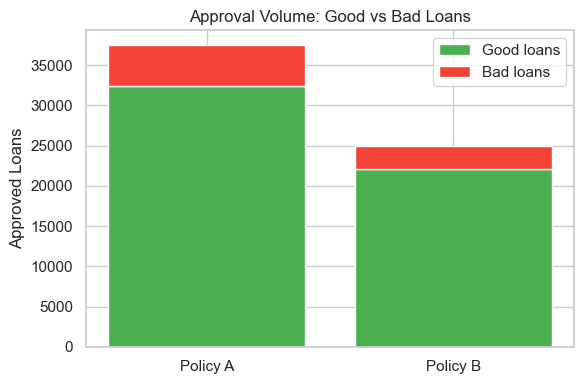

In [40]:
# -- Fig 5: Approval volume stacked bar --
plt.figure(figsize=(6, 4))
plt.bar(['Policy A', 'Policy B'],
        [n_A - bad_A, n_B - bad_B], color='#4CAF50', label='Good loans')
plt.bar(['Policy A', 'Policy B'],
        [bad_A, bad_B], bottom=[n_A - bad_A, n_B - bad_B],
        color='#F44336', label='Bad loans')
plt.ylabel('Approved Loans')
plt.title('Approval Volume: Good vs Bad Loans')
plt.legend()
plt.tight_layout()
plt.savefig('fig5_volume.png', dpi=150)
plt.show()

# Q2

In [20]:
# ============================================================
# Q2 — CLUSTERING DATA PREPARATION
# ============================================================

# 1. Define clustering features
# NOTE:
# - We only use borrower-related numeric characteristics
# - Exclude target (loan_is_bad)
# - Exclude grade (platform assigned credit signal)
# - Exclude any post-outcome variables (already removed in Q1)

cluster_features = [
    'term',          # repayment length (36 / 60 months)
    'dti',           # debt-to-income ratio
    'annual_inc',    # annual income (winsorised in Q1)
    'revol_util',    # revolving utilisation (capped at 1.0 in Q1)
    'delinq_2yrs',   # past delinquencies
    'loan_amnt'      # loan size
]

# 2. Create clustering dataset from CLEANED data
df_cluster = dfclean[cluster_features].copy()

# ------------------------------------------------------------
# Convert term to binary indicator
# 36 months -> 0 (short-term)
# 60 months -> 1 (long-term)
# ------------------------------------------------------------
df_cluster['term'] = df_cluster['term'].replace({36: 0, 60: 1})

# ------------------------------------------------------------
# Summary BEFORE standardisation
# ------------------------------------------------------------
print("=== Summary Statistics BEFORE Standardisation ===")
print(df_cluster.describe().round(2))

=== Summary Statistics BEFORE Standardisation ===
           term       dti  annual_inc  revol_util  delinq_2yrs  loan_amnt
count  49969.00  49969.00    49969.00    49969.00     49969.00   49969.00
mean       0.19     17.37    69684.49        0.59         0.22   13903.91
std        0.39      7.77    37102.63        0.23         0.67    8085.39
min        0.00      0.00     5000.00        0.00         0.00    1000.00
25%        0.00     11.51    45000.00        0.43         0.00    8000.00
50%        0.00     17.17    60000.00        0.62         0.00   12000.00
75%        0.00     23.05    85000.00        0.78         0.00   19200.00
max        1.00     34.99   225000.00        1.00        18.00   35000.00


In [21]:
# ============================================================
# Q2 — Correlation Check
# ============================================================

# Use cleaned clustering dataset
corr_matrix = df_cluster.corr(numeric_only=True)
print("=== Correlation Matrix ===")
print(round(corr_matrix, 2))

=== Correlation Matrix ===
             term   dti  annual_inc  revol_util  delinq_2yrs  loan_amnt
term         1.00  0.08        0.14        0.06         0.01       0.47
dti          0.08  1.00       -0.24        0.25        -0.00       0.04
annual_inc   0.14 -0.24        1.00        0.03         0.09       0.46
revol_util   0.06  0.25        0.03        1.00        -0.00       0.09
delinq_2yrs  0.01 -0.00        0.09       -0.00         1.00       0.02
loan_amnt    0.47  0.04        0.46        0.09         0.02       1.00


In [22]:
# ============================================================
# Q2 — Standardisation
# ============================================================

# 1. Define Features: Continuous vs Binary
continuous_features = [
    'dti',
    'annual_inc',
    'revol_util',
    'delinq_2yrs',
    'loan_amnt'
]

binary_features = ['term']   # already converted to 0 / 1 earlier


# 2. Initialise scaler
scaler = StandardScaler()

# 3. Fit + Transform (ONLY continuous variables)
df_cluster_scaled = df_cluster.copy()

df_cluster_scaled[continuous_features] = scaler.fit_transform(
    df_cluster[continuous_features]
)

# ------------------------------------------------------------
# Summary AFTER Standardisation
# ------------------------------------------------------------
print("\n=== Summary Statistics AFTER Standardisation ===")
print("Expected: mean ≈ 0, std ≈ 1 (continuous only)")
print(df_cluster_scaled[continuous_features + binary_features]
      .describe()
      .round(2))


=== Summary Statistics AFTER Standardisation ===
Expected: mean ≈ 0, std ≈ 1 (continuous only)
            dti  annual_inc  revol_util  delinq_2yrs  loan_amnt      term
count  49969.00    49969.00    49969.00     49969.00   49969.00  49969.00
mean      -0.00       -0.00       -0.00        -0.00       0.00      0.19
std        1.00        1.00        1.00         1.00       1.00      0.39
min       -2.24       -1.74       -2.52        -0.33      -1.60      0.00
25%       -0.76       -0.67       -0.67        -0.33      -0.73      0.00
50%       -0.03       -0.26        0.11        -0.33      -0.24      0.00
75%        0.73        0.41        0.80        -0.33       0.66      0.00
max        2.27        4.19        1.76        26.48       2.61      1.00


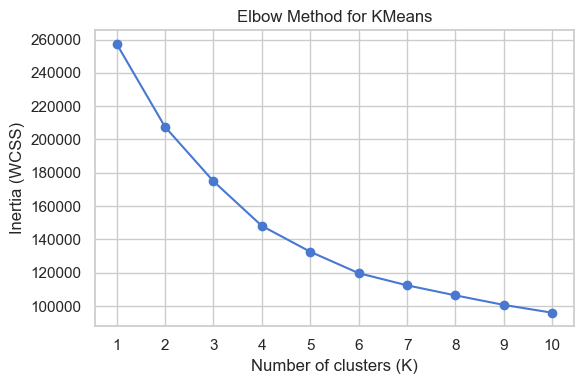

In [23]:
# ============================================================
# Q2 — Elbow Method (KMeans)
# ============================================================

# Use only clustering features (continuous scaled + binary term)
feature_cols = continuous_features + binary_features
X = df_cluster_scaled[feature_cols].values  # convert to numpy array

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm="lloyd"
    )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for KMeans")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

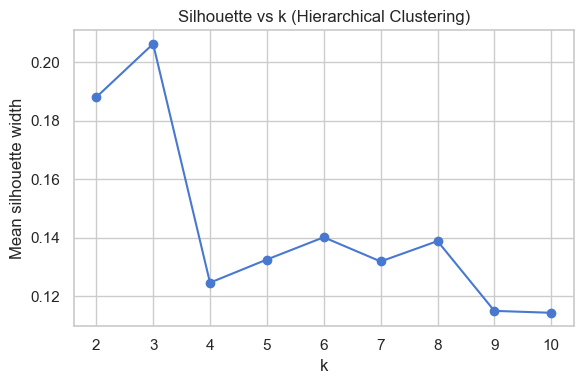

In [24]:
# ============================================================
# Q2 — Silhouette vs k (Hierarchical, sampled)
# ============================================================

# Use clustering features
feature_cols = continuous_features + binary_features
X = df_cluster_scaled[feature_cols].values

# ------------------------------------------------------------
# Sampling to speed up
# ------------------------------------------------------------
np.random.seed(42)
sample_size = 4000   

if len(X) <= sample_size:
    X_sample = X
else:
    idx = np.random.choice(len(X), sample_size, replace=False)
    X_sample = X[idx]

# ------------------------------------------------------------
# Compute silhouette for different k
# ------------------------------------------------------------
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    hc = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    labels = hc.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Mean silhouette width")
plt.title("Silhouette vs k (Hierarchical Clustering)")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [25]:
# -------------------------------------------------
# Step 1: Set number of clusters
# -------------------------------------------------
K = 3

feature_cols = continuous_features + binary_features
X = df_cluster_scaled[feature_cols].values

# -------------------------------------------------
# Step 2: Run KMeans on FULL dataset
# -------------------------------------------------
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

# Assign cluster labels
df_cluster = df_cluster.copy()
df_cluster["Cluster"] = labels


# -------------------------------------------------
# Step 3: Cluster Profile (Original Scale)
# -------------------------------------------------
cluster_profile = (
    df_cluster
    .groupby("Cluster")[continuous_features + binary_features]
    .mean()
)

print("=== Cluster Profile (Original Scale) ===")
print(cluster_profile.round(2))


# -------------------------------------------------
# Step 4: Cluster Size
# -------------------------------------------------
cluster_size = (
    df_cluster["Cluster"]
    .value_counts()
    .sort_index()
)

print("\n=== Cluster Size ===")
print(cluster_size)

=== Cluster Profile (Original Scale) ===
           dti  annual_inc  revol_util  delinq_2yrs  loan_amnt  term
Cluster                                                             
0        15.39   113096.96        0.63         0.40   23652.20  0.41
1        22.73    53877.40        0.70         0.16   11680.75  0.15
2        11.68    59362.99        0.40         0.19    9818.85  0.08

=== Cluster Size ===
Cluster
0    11823
1    21792
2    16354
Name: count, dtype: int64


In [26]:
# Make sure index alignment is preserved
dfclean = dfclean.copy()
dfclean["Cluster"] = labels

# ============================================================
# Baseline Default Rate by Cluster (No Policy Filter)
# ============================================================

baseline = (
    dfclean
    .groupby("Cluster")["loan_is_bad"]
    .mean()
)

print("=== Baseline Default Rate by Cluster ===")
print((baseline * 100).round(2))

clusters = sorted(dfclean["Cluster"].unique())

for c in clusters:
    
    print("="*50)
    print(f"Cluster {c}")
    print("="*50)
    
    df_c = dfclean[dfclean["Cluster"] == c].copy()
    
    # ---------------- Policy A ----------------
    policy_a = df_c['grade'].isin(['A','B','C','D']) & (df_c['dti'] < 25)
    approved_A = df_c[policy_a]
    
    FN_A = (approved_A['loan_is_bad'] == 1).sum()
    n_A  = len(approved_A)
    
    # ---------------- Policy B ----------------
    policy_b = df_c['grade'].isin(['A','B','C']) & (df_c['dti'] < 20)
    approved_B = df_c[policy_b]
    
    FN_B = (approved_B['loan_is_bad'] == 1).sum()
    n_B  = len(approved_B)
    
    dr_A = FN_A / n_A
    dr_B = FN_B / n_B
    
    # ---------------- Z-test ----------------
    count = np.array([FN_A, FN_B])
    nobs  = np.array([n_A, n_B])
    
    z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
    
    print(f"Policy A Default Rate: {dr_A:.3f} ({dr_A*100:.1f}%)")
    print(f"Policy B Default Rate: {dr_B:.3f} ({dr_B*100:.1f}%)")
    print(f"z = {z_stat:.3f}, p = {p_value:.4f}")
    
    if p_value < 0.05:
        print("→ Significant: Policy A has higher default rate\n")
    else:
        print("→ Not statistically significant\n")

=== Baseline Default Rate by Cluster ===
Cluster
0    15.40
1    18.27
2    12.26
Name: loan_is_bad, dtype: float64
Cluster 0
Policy A Default Rate: 0.119 (11.9%)
Policy B Default Rate: 0.098 (9.8%)
z = 4.011, p = 0.0000
→ Significant: Policy A has higher default rate

Cluster 1
Policy A Default Rate: 0.165 (16.5%)
Policy B Default Rate: 0.141 (14.1%)
z = 4.120, p = 0.0000
→ Significant: Policy A has higher default rate

Cluster 2
Policy A Default Rate: 0.119 (11.9%)
Policy B Default Rate: 0.109 (10.9%)
z = 2.784, p = 0.0027
→ Significant: Policy A has higher default rate



# Q3 - Deep Learning for Default Prediction

In [27]:
# -----------------------------
# Feature selection
# -----------------------------

features = [
    'loan_amnt',
    'term',
    'int_rate',
    'dti',
    'annual_inc',
    'revol_util',
    'inq_last_6mths',
    'delinq_2yrs',
    'emp_length',
 #   'grade'
]

target = 'loan_is_bad'

X = dfclean[features].copy()
y = dfclean[target].astype(float)

In [28]:
# -----------------------------
# Train / Val / Test split
# -----------------------------

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # gives 15% validation overall
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (34997, 9)
Validation: (7476, 9)
Test: (7496, 9)


In [29]:
# -----------------------------
# Standardise features
# -----------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [30]:
# -----------------------------
# Convert to tensors
# -----------------------------

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val   = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print("Tensor shapes:")
print(X_train.shape, y_train.shape)
print("Default rate in training set:", y_train.mean().item())

Tensor shapes:
torch.Size([34997, 9]) torch.Size([34997, 1])
Default rate in training set: 0.15627053380012512


In [31]:
# -----------------------------
# Creating a function for model evaluation
# -----------------------------

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds_class = (probs >= 0.5).float()
    y_true = y.numpy().ravel()
    y_pred = preds_class.numpy().ravel()
    y_prob = probs.numpy().ravel()
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Accuracy :", round(acc,4))
    print("AUC      :", round(auc,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

## Model 1 - Simple Neural Network

In [49]:
class Model1(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = Model1(input_dim)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor(pos_weight)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
patience = 30

best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss = criterion(val_logits, y_val)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model = model.state_dict()
    else:
        patience_counter += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model.load_state_dict(best_model)

Epoch 0 | Train Loss: 1.1829 | Val Loss: 1.1810
Epoch 20 | Train Loss: 1.1592 | Val Loss: 1.1591
Epoch 40 | Train Loss: 1.1424 | Val Loss: 1.1441
Epoch 60 | Train Loss: 1.1293 | Val Loss: 1.1327
Epoch 80 | Train Loss: 1.1192 | Val Loss: 1.1243
Epoch 100 | Train Loss: 1.1122 | Val Loss: 1.1185
Epoch 120 | Train Loss: 1.1075 | Val Loss: 1.1145
Epoch 140 | Train Loss: 1.1044 | Val Loss: 1.1116
Epoch 160 | Train Loss: 1.1022 | Val Loss: 1.1096
Epoch 180 | Train Loss: 1.1006 | Val Loss: 1.1082
Epoch 200 | Train Loss: 1.0995 | Val Loss: 1.1073
Epoch 220 | Train Loss: 1.0986 | Val Loss: 1.1067
Epoch 240 | Train Loss: 1.0979 | Val Loss: 1.1063
Epoch 260 | Train Loss: 1.0973 | Val Loss: 1.1061
Epoch 280 | Train Loss: 1.0969 | Val Loss: 1.1059
Epoch 300 | Train Loss: 1.0965 | Val Loss: 1.1058
Epoch 320 | Train Loss: 1.0962 | Val Loss: 1.1056
Epoch 340 | Train Loss: 1.0958 | Val Loss: 1.1055
Epoch 360 | Train Loss: 1.0955 | Val Loss: 1.1052
Epoch 380 | Train Loss: 1.0952 | Val Loss: 1.1050
Epoch 

<All keys matched successfully>

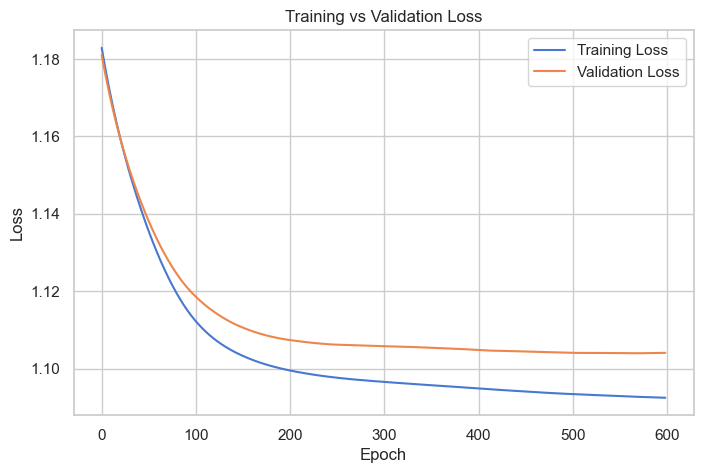

In [50]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [51]:
print("Validation set - Evaluation metrics : \n")
evaluate_model(model, X_val, y_val)
print("\nTest set - Evaluation metrics : \n")
evaluate_model(model, X_test, y_test)

Validation set - Evaluation metrics : 

Accuracy : 0.5979
AUC      : 0.657
Precision: 0.2237
Recall   : 0.637
F1 Score : 0.3311

Test set - Evaluation metrics : 

Accuracy : 0.6166
AUC      : 0.6677
Precision: 0.2351
Recall   : 0.6456
F1 Score : 0.3447


## Model 2 - Deeper Neural Network

In [52]:
class Model2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model2 = Model2(input_dim)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor(pos_weight)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model2.parameters(), lr=0.001)

epochs = 1000
patience = 10

best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model2.eval()
    with torch.no_grad():
        val_logits = model2(X_val)
        val_loss = criterion(val_logits, y_val)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model = model2.state_dict()
    else:
        patience_counter += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

model2.load_state_dict(best_model)

Epoch 0 | Train Loss: 1.1721 | Val Loss: 1.1711
Epoch 20 | Train Loss: 1.1461 | Val Loss: 1.1467
Epoch 40 | Train Loss: 1.1194 | Val Loss: 1.1216
Epoch 60 | Train Loss: 1.1033 | Val Loss: 1.1095
Epoch 80 | Train Loss: 1.0987 | Val Loss: 1.1086
Epoch 100 | Train Loss: 1.0965 | Val Loss: 1.1066
Epoch 120 | Train Loss: 1.0950 | Val Loss: 1.1060
Epoch 140 | Train Loss: 1.0937 | Val Loss: 1.1053
Epoch 160 | Train Loss: 1.0925 | Val Loss: 1.1046
Epoch 180 | Train Loss: 1.0913 | Val Loss: 1.1043
Epoch 200 | Train Loss: 1.0902 | Val Loss: 1.1039
Epoch 220 | Train Loss: 1.0893 | Val Loss: 1.1035
Epoch 240 | Train Loss: 1.0884 | Val Loss: 1.1034
Epoch 260 | Train Loss: 1.0875 | Val Loss: 1.1033
Epoch 280 | Train Loss: 1.0866 | Val Loss: 1.1032
Epoch 300 | Train Loss: 1.0858 | Val Loss: 1.1032

Early stopping at epoch 306


<All keys matched successfully>

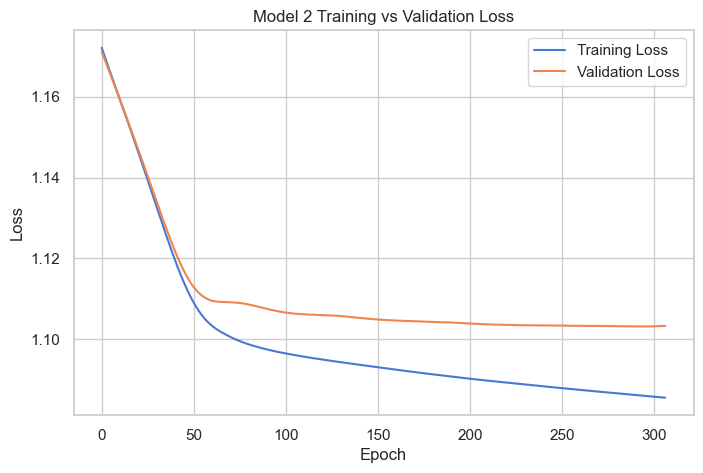

In [53]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 Training vs Validation Loss")
plt.legend()
plt.show()

In [37]:
print("Validation set - Evaluation metrics:\n")
evaluate_model(model2, X_val, y_val)

print("\nTest set - Evaluation metrics:\n")
evaluate_model(model2, X_test, y_test)

Validation set - Evaluation metrics:

Accuracy : 0.5964
AUC      : 0.6565
Precision: 0.2225
Recall   : 0.6344
F1 Score : 0.3294

Test set - Evaluation metrics:

Accuracy : 0.6145
AUC      : 0.6664
Precision: 0.2358
Recall   : 0.655
F1 Score : 0.3467


## Model 3 - Deep Neural Network with Regularisation

In [54]:
class Model3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(    
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)
        
input_dim = X_train.shape[1]
model3 = Model3(input_dim)

pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
pos_weight = torch.tensor(pos_weight)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model3.parameters(), lr=0.001)
epochs = 1000
patience = 20
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model3.train()
    logits = model3(X_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model3.eval()
    with torch.no_grad():
        val_logits = model3(X_val)
        val_loss = criterion(val_logits, y_val)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model = model3.state_dict()
    else:
        patience_counter += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break
        
model3.load_state_dict(best_model)

Epoch 0 | Train Loss: 1.1796 | Val Loss: 1.1692
Epoch 20 | Train Loss: 1.1191 | Val Loss: 1.1203
Epoch 40 | Train Loss: 1.1071 | Val Loss: 1.1068
Epoch 60 | Train Loss: 1.1047 | Val Loss: 1.1054
Epoch 80 | Train Loss: 1.1026 | Val Loss: 1.1051
Epoch 100 | Train Loss: 1.1019 | Val Loss: 1.1048
Epoch 120 | Train Loss: 1.1000 | Val Loss: 1.1046
Epoch 140 | Train Loss: 1.0991 | Val Loss: 1.1045
Epoch 160 | Train Loss: 1.0995 | Val Loss: 1.1043
Epoch 180 | Train Loss: 1.0978 | Val Loss: 1.1039
Epoch 200 | Train Loss: 1.0965 | Val Loss: 1.1038
Epoch 220 | Train Loss: 1.0967 | Val Loss: 1.1037

Early stopping at epoch 231


<All keys matched successfully>

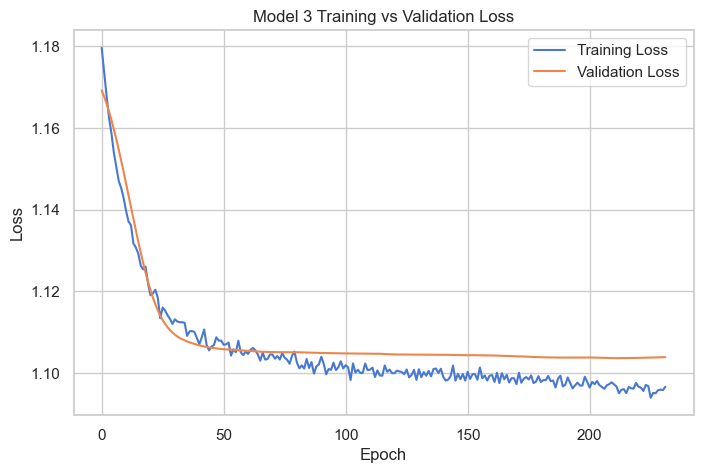

In [55]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 Training vs Validation Loss")
plt.legend()
plt.show()

In [56]:
print("Validation set - Evaluation metrics:\n")
evaluate_model(model3, X_val, y_val)

print("\nTest set - Evaluation metrics:\n")
evaluate_model(model3, X_test, y_test)

Validation set - Evaluation metrics:

Accuracy : 0.5883
AUC      : 0.6551
Precision: 0.2222
Recall   : 0.6541
F1 Score : 0.3317

Test set - Evaluation metrics:

Accuracy : 0.6073
AUC      : 0.669
Precision: 0.2342
Recall   : 0.667
F1 Score : 0.3466


## Model Comparison

In [57]:
def get_metrics(model, X, y):

    model.eval()

    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds_class = (probs >= 0.5).float()

    y_true = y.numpy().ravel()
    y_pred = preds_class.numpy().ravel()
    y_prob = probs.numpy().ravel()

    auc = roc_auc_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return auc, precision, recall, f1

auc1, prec1, rec1, f11 = get_metrics(model, X_test, y_test)
auc2, prec2, rec2, f12 = get_metrics(model2, X_test, y_test)
auc3, prec3, rec3, f13 = get_metrics(model3, X_test, y_test)

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Architecture": [
        "1 hidden layer",
        "2 hidden layers",
        "Deep + regularisation"
    ],
    "Test AUC": [auc1, auc2, auc3],
    "Precision": [prec1, prec2, prec3],
    "Recall": [rec1, rec2, rec3],
    "F1": [f11, f12, f13]
})

results = results.round(3)

print(results)

     Model           Architecture  Test AUC  Precision  Recall     F1
0  Model 1         1 hidden layer     0.668      0.235   0.646  0.345
1  Model 2        2 hidden layers     0.666      0.236   0.655  0.347
2  Model 3  Deep + regularisation     0.669      0.234   0.667  0.347


### Confusion matrix analysis

In [66]:
def get_conf_matrix(model, X, y):
    model.eval()
    
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

    y_true = y.numpy().ravel()
    y_pred = preds.numpy().ravel()

    cm = confusion_matrix(y_true, y_pred)
    return cm

cm1 = get_conf_matrix(model, X_test, y_test)
cm2 = get_conf_matrix(model2, X_test, y_test)
cm3 = get_conf_matrix(model3, X_test, y_test)

def print_cm(cm, name):
    print(f"\n{name} Confusion Matrix:")
    print("TN:", cm[0,0], " FP:", cm[0,1])
    print("FN:", cm[1,0], " TP:", cm[1,1])

print_cm(cm1, "Model 1")
print_cm(cm2, "Model 2")
print_cm(cm3, "Model 3")


Model 1 Confusion Matrix:
TN: 3866  FP: 2459
FN: 415  TP: 756

Model 2 Confusion Matrix:
TN: 3839  FP: 2486
FN: 404  TP: 767

Model 3 Confusion Matrix:
TN: 3771  FP: 2554
FN: 390  TP: 781


### Model Performance by Cluster

In [58]:
def evaluate_by_cluster(model, model_name):
    cluster_metrics = []
    clusters = sorted(dfclean["Cluster"].unique())
    for c in clusters:
        df_c = dfclean[dfclean["Cluster"] == c]
        X_c = df_c[features]
        y_c = df_c[target]
        X_c_scaled = scaler.transform(X_c)
        X_c_tensor = torch.tensor(X_c_scaled, dtype=torch.float32)
        model.eval()
        with torch.no_grad():
            logits = model(X_c_tensor)
            probs = torch.sigmoid(logits).numpy().ravel()
        auc = roc_auc_score(y_c, probs)
        preds = (probs >= 0.5).astype(int)
        precision = precision_score(y_c, preds)
        recall = recall_score(y_c, preds)
        f1 = f1_score(y_c, preds)
        cluster_metrics.append([model_name, c, auc, precision, recall, f1])
    return pd.DataFrame(
        cluster_metrics,
        columns=["Model","Cluster","AUC","Precision","Recall","F1"]
    )

res1 = evaluate_by_cluster(model, "Model 1")
res2 = evaluate_by_cluster(model2, "Model 2")
res3 = evaluate_by_cluster(model3, "Model 3")

cluster_results = pd.concat([res1, res2, res3])

#print(cluster_results.round(3))
print(res1)
print("\n")
print(res2)
print("\n")
print(res3)

     Model  Cluster       AUC  Precision    Recall        F1
0  Model 1        0  0.684678   0.241720  0.645250  0.351691
1  Model 1        1  0.640536   0.231397  0.741085  0.352674
2  Model 1        2  0.661657   0.207499  0.449875  0.284005


     Model  Cluster       AUC  Precision    Recall        F1
0  Model 2        0  0.691575   0.245177  0.669962  0.358982
1  Model 2        1  0.644310   0.233907  0.744601  0.355985
2  Model 2        2  0.667275   0.210526  0.468828  0.290572


     Model  Cluster       AUC  Precision    Recall        F1
0  Model 3        0  0.686668   0.239480  0.678199  0.353970
1  Model 3        1  0.642586   0.230262  0.762431  0.353702
2  Model 3        2  0.665547   0.211353  0.469825  0.291551


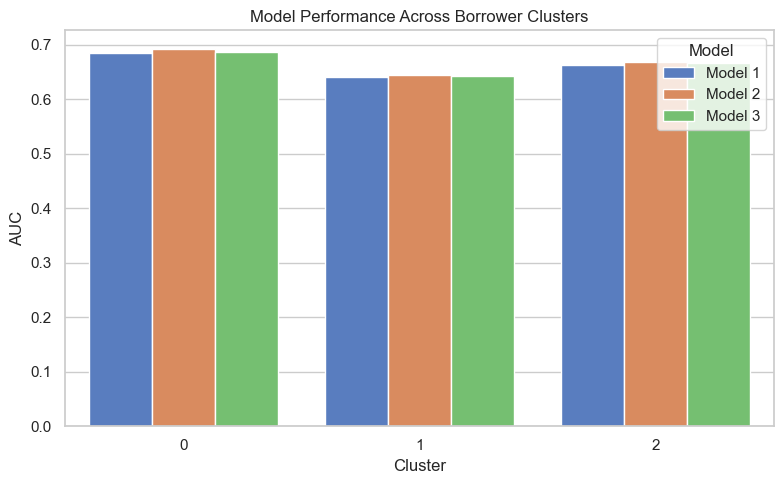

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cluster_results,
    x="Cluster",
    y="AUC",
    hue="Model"
)

plt.title("Model Performance Across Borrower Clusters")
plt.ylabel("AUC")
plt.xlabel("Cluster")

plt.tight_layout()
plt.show()

### Comparison of Actual vs Predicted Default Rate by Cluster 

In [60]:
# ============================================================
# Function to compute actual vs predicted default rate & FNR
# ============================================================

def cluster_default_analysis(model, model_name, threshold=0.5):
    """
    Compute actual vs predicted default rate and FNR by cluster
    Args:
        model: trained PyTorch model
        model_name: str, name for labeling plots
        threshold: probability threshold for classifying default
    Returns:
        df_metrics: DataFrame with cluster, actual DR, predicted DR, FNR
    """
    clusters = sorted(dfclean["Cluster"].unique())
    metrics = []

    for c in clusters:
        df_c = dfclean[dfclean["Cluster"] == c].copy()
        X_c = df_c[features]
        y_c = df_c[target].astype(int)

        # Convert features to scaled tensor
        X_c_scaled = scaler.transform(X_c)
        X_c_tensor = torch.tensor(X_c_scaled, dtype=torch.float32)

        # Model predictions
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(X_c_tensor)).numpy().ravel()
        preds = (probs >= threshold).astype(int)

        # Default rate logic (like Q1: only approved loans are considered)
        # Define "approved" for Q1-style logic
        approved = (df_c['grade'].isin(['A','B','C','D'])) & (df_c['dti'] <= 25)
        approved_y = y_c[approved]
        approved_preds = preds[approved.values]

        # Actual default rate among approved loans
        actual_dr = approved_y.sum() / len(approved_y) if len(approved_y) > 0 else np.nan
        # Predicted default rate among approved loans
        pred_dr = approved_preds.sum() / len(approved_preds) if len(approved_preds) > 0 else np.nan
        # False negative rate among approved loans
        fnr = ((approved_y == 1) & (approved_preds == 0)).sum() / len(approved_y) if len(approved_y) > 0 else np.nan

        metrics.append([c, actual_dr, pred_dr, fnr])

    df_metrics = pd.DataFrame(
        metrics, columns=["Cluster", "Actual_DR", "Predicted_DR", "FNR"]
    )
    df_metrics["Model"] = model_name
    return df_metrics

# ============================================================
# Compute metrics for all 3 models
# ============================================================

df_m1 = cluster_default_analysis(model, "Model 1")
df_m2 = cluster_default_analysis(model2, "Model 2")
df_m3 = cluster_default_analysis(model3, "Model 3")

cluster_metrics = pd.concat([df_m1, df_m2, df_m3], ignore_index=True)
print(cluster_metrics.round(3))

   Cluster  Actual_DR  Predicted_DR    FNR    Model
0        0      0.119         0.245  0.069  Model 1
1        1      0.165         0.507  0.054  Model 1
2        2      0.119         0.252  0.069  Model 1
3        0      0.119         0.258  0.064  Model 2
4        1      0.165         0.502  0.054  Model 2
5        2      0.119         0.259  0.066  Model 2
6        0      0.119         0.272  0.063  Model 3
7        1      0.165         0.524  0.051  Model 3
8        2      0.119         0.259  0.066  Model 3


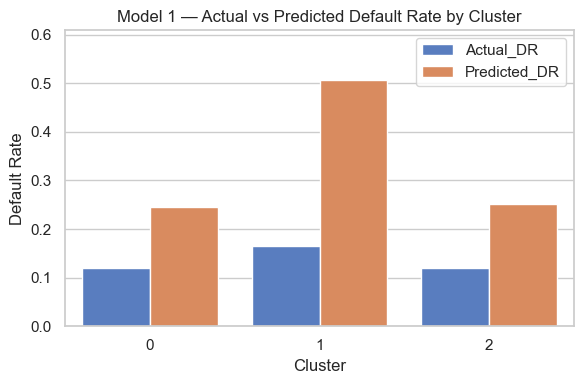

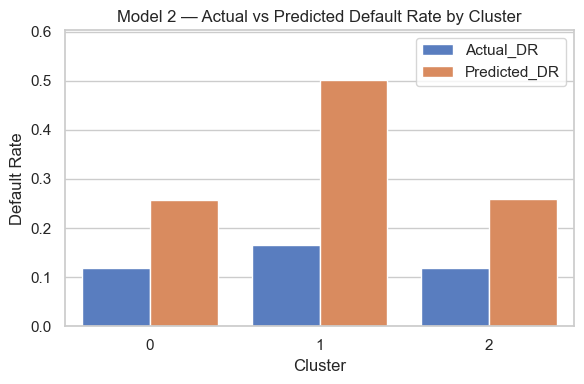

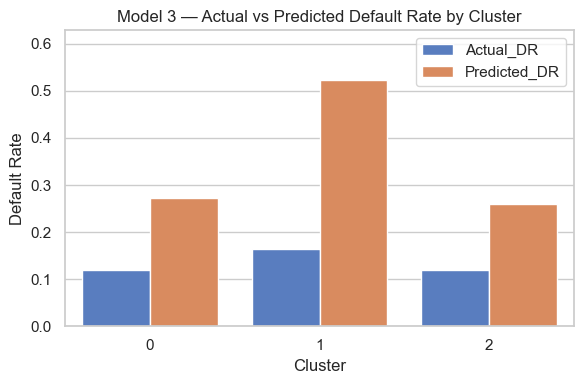

In [61]:
# ============================================================
# Plot Actual vs Predicted Default Rate by Cluster
# ============================================================

for m_name, df_plot in cluster_metrics.groupby("Model"):
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df_plot.melt(id_vars='Cluster', value_vars=['Actual_DR','Predicted_DR']),
        x='Cluster', y='value', hue='variable'
    )
    plt.title(f"{m_name} — Actual vs Predicted Default Rate by Cluster")
    plt.ylabel("Default Rate")
    plt.xlabel("Cluster")
    plt.ylim(0, df_plot[['Actual_DR','Predicted_DR']].max().max() * 1.2)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()


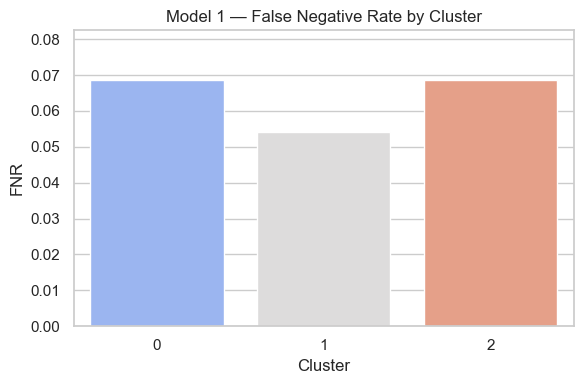

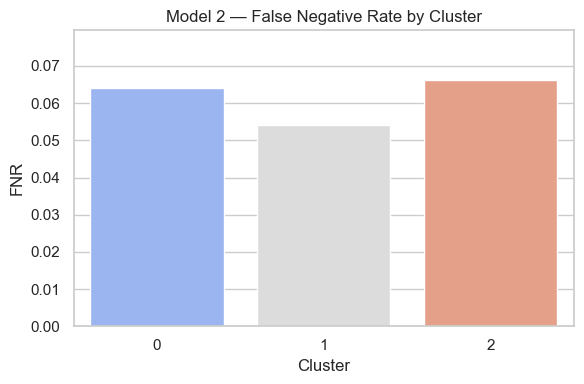

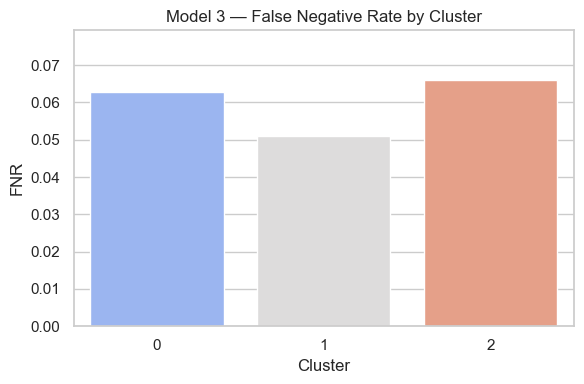

In [62]:
# ============================================================
# Plot False Negative Rate by Cluster
# ============================================================

for m_name, df_plot in cluster_metrics.groupby("Model"):
    plt.figure(figsize=(6,4))
    sns.barplot(
        data=df_plot, x="Cluster", y="FNR", palette="coolwarm"
    )
    plt.title(f"{m_name} — False Negative Rate by Cluster")
    plt.ylabel("FNR")
    plt.xlabel("Cluster")
    plt.ylim(0, df_plot["FNR"].max() * 1.2)
    plt.tight_layout()
    plt.show()